In [55]:
import pandas as pd
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [56]:
df.shape

(10000, 14)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [58]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [59]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


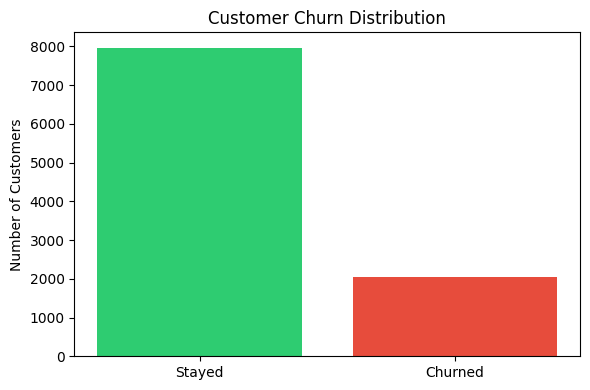

Churn Rate: 20.37%


In [60]:
import matplotlib.pyplot as plt

churn_counts = df['Exited'].value_counts()
labels = ['Stayed', 'Churned']
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6,4))
plt.bar(labels, churn_counts.values, color=colors)
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(f"Churn Rate: {df['Exited'].mean()*100:.2f}%")

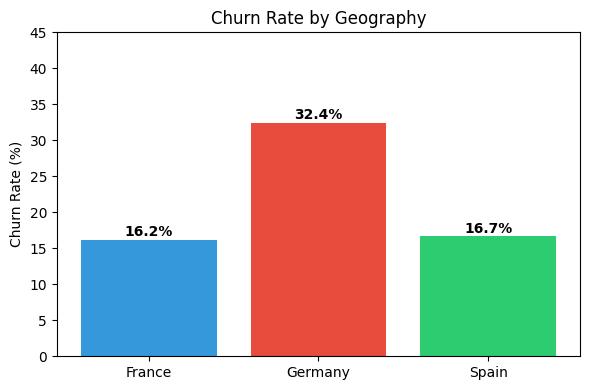

In [61]:
geo_churn = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(geo_churn.index, geo_churn.values,
               color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 45)

for bar, val in zip(bars, geo_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

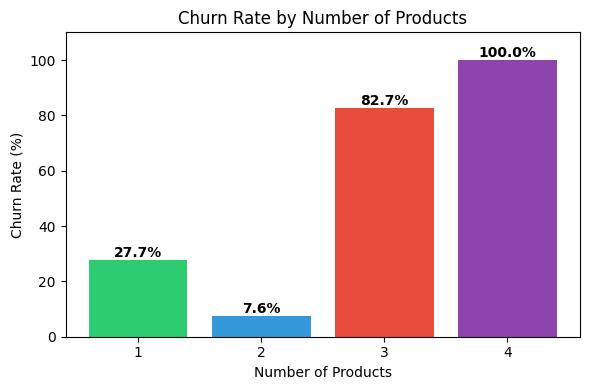

In [62]:
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(prod_churn.index.astype(str), prod_churn.values,
               color=['#2ecc71', '#3498db', '#e74c3c', '#8e44ad'])
plt.title('Churn Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 110)

for bar, val in zip(bars, prod_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

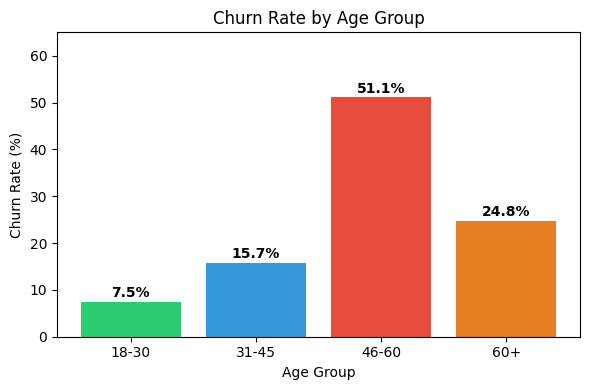

In [63]:
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(6,4))
bars = plt.bar(age_churn.index.astype(str), age_churn.values,
               color=['#2ecc71', '#3498db', '#e74c3c', '#e67e22'])
plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 65)

for bar, val in zip(bars, age_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [64]:
from sklearn.preprocessing import LabelEncoder

df_model = df.drop(['RowNumber', 'CustomerId', 'Surname', 'AgeGroup'], axis=1)

le = LabelEncoder()
df_model['Geography'] = le.fit_transform(df_model['Geography'])
df_model['Gender'] = le.fit_transform(df_model['Gender'])

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [65]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 81.60%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [67]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
}).sort_values('Importance', ascending=False)

print(feature_importance)

           Feature    Importance
8   IsActiveMember  1.129779e+00
2           Gender  5.069731e-01
1        Geography  2.520359e-01
7        HasCrCard  1.247477e-01
6    NumOfProducts  8.923438e-02
3              Age  6.358505e-02
4           Tenure  3.173269e-02
0      CreditScore  2.639204e-03
5          Balance  4.018188e-06
9  EstimatedSalary  5.210544e-07
